# Uneven New York: Ethnicity, Income, and the Problem of Comparing Census Counts

This notebook explores a New York City census dataset through a question that is both spatial and methodological:

> **Where do high Hispanic or Latino population shares and high concentrations of households earning below $25,000 overlap, and how does the answer change when we map raw counts instead of percentages?**

I chose these variables because they can support a preliminary investigation of uneven social vulnerability. At the same time, both variables can be easily misread. A high count may simply reflect a large population, while a high percentage describes composition rather than the number of affected residents.

The analysis therefore moves step by step from **metadata → raw counts → distributions → normalized percentages → maps → non-map comparisons → limitations**. This structure follows the logic of the course tutorial while developing an independent research question.


## 1. Setup and data loading

The notebook uses a FlatGeobuf census file because it preserves geometry and attributes in one compact geospatial format. The code searches for the file automatically so the notebook can run on another computer without editing a hard-coded path.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 10

candidates = [
    Path("census_nyc_sp.fgb"),
    Path("data/census_nyc_sp.fgb"),
    Path("../census_nyc_sp.fgb"),
]

data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
    matches = list(Path.cwd().rglob("census_nyc_sp.fgb"))
    if not matches:
        raise FileNotFoundError(
            "Place census_nyc_sp.fgb in the same folder as this notebook or in a data folder."
        )
    data_path = matches[0]

census = gpd.read_file(data_path)
print("Loaded:", data_path.resolve())
print("Rows:", len(census))
print("CRS:", census.crs)

Loaded: /Users/elian/Desktop/cdp-mapping-systems/content/Assignments/assignment 1/census_nyc_sp.fgb
Rows: 6593
CRS: EPSG:2263


In [2]:
census.head()

,GISJOIN,Total Pop (Race/Ethnicity),Not Hispanic or Latino,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some other race alone,Not Hispanic or Latino: Two or more races,...,"$100,000 to $124,999","$125,000 to $149,999","$150,000 to $199,999","$200,000 or more",COUNTY,TRACTCE,BLKGRPCE,Area (Sq Mi),zip_code,geometry
0,G36008101010021,3837,3817,3817,0,0,0,0,0,0,...,94,30,164,276,Queens County,101002,1,0.157620,11691,"MULTIPOLYGON (((1056895.943 157320.531, 105674..."
1,G36008101010022,2275,1803,648,350,0,794,0,0,11,...,88,0,0,204,Queens County,101002,2,0.048883,11691,"MULTIPOLYGON (((1057018.771 155993.29, 1056995..."
2,G36008101010043,2123,1506,487,766,0,243,0,0,10,...,58,0,41,28,Queens County,101004,3,0.039452,11691,"MULTIPOLYGON (((1055223.035 157038.704, 105528..."
3,G36008101010042,1464,1342,576,718,0,9,0,0,39,...,0,0,0,0,Queens County,101004,2,0.054139,11691,"MULTIPOLYGON (((1055223.035 157038.704, 105498..."
4,G36008101010032,467,195,90,76,0,12,0,0,17,...,0,0,26,0,Queens County,101003,2,0.013168,11691,"MULTIPOLYGON (((1054329.195 158352.062, 105414..."


## 2. Metadata and attribute audit

Before choosing variables, I need to know what each row represents, whether geometries are valid, and which fields can be used as denominators. This prevents a common mapping mistake: visualizing a field before understanding its unit.


In [3]:
print("Geometry types:")
print(census.geometry.geom_type.value_counts())

print("\nMissing geometries:", census.geometry.isna().sum())
print("Invalid geometries:", (~census.geometry.is_valid).sum())

print("\nSpatial extent [minx, miny, maxx, maxy]:")
print(census.total_bounds)

print("\nNumber of attributes:", len(census.columns))
print(census.columns.tolist())

Geometry types:
MultiPolygon    6593
Name: count, dtype: int64

Missing geometries: 0
Invalid geometries: 0

Spatial extent [minx, miny, maxx, maxy]:
[ 913141.17384133  120096.26607439 1067337.91749927  272752.87352883]

Number of attributes: 36
['GISJOIN', 'Total Pop (Race/Ethnicity)', 'Not Hispanic or Latino', 'Not Hispanic or Latino: White alone', 'Not Hispanic or Latino: Black or African American alone', 'Not Hispanic or Latino: American Indian and Alaska Native alone', 'Not Hispanic or Latino: Asian alone', 'Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone', 'Not Hispanic or Latino: Some other race alone', 'Not Hispanic or Latino: Two or more races', 'Not Hispanic or Latino: Two or more races: Two races including Some other race', 'Not Hispanic or Latino: Two or more races: Two races excluding Some other race, and three or more races', 'Hispanic or Latino', 'Total Households (Income)', 'Less than $10,000', '$10,000 to $14,999', '$15,000 to $19,999', '$20,00

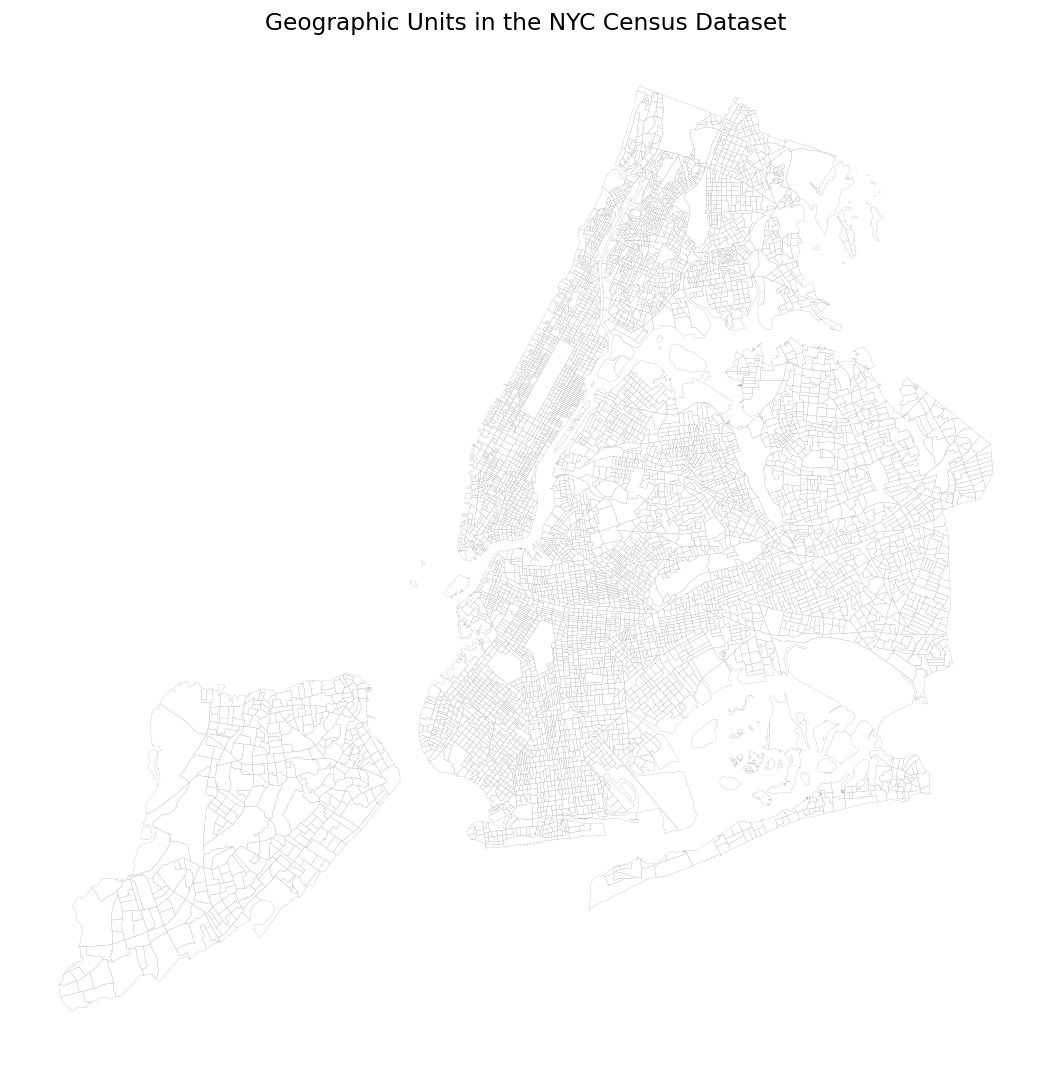

In [4]:
# Basic view of the geographic units
fig, ax = plt.subplots(figsize=(9, 9))
census.plot(ax=ax, facecolor="white", edgecolor="0.65", linewidth=0.15)
ax.set_title("Geographic Units in the NYC Census Dataset")
ax.set_axis_off()
plt.tight_layout()
plt.show()

The polygons are census reporting units, not naturally occurring neighborhoods. Their boundaries affect every later statistic. This is important because a map may appear precise even though its units are administrative constructions.


## 3. Attribute choice

I focus on two themes:

1. **Hispanic or Latino population**
2. **Households with annual income below $25,000**

The dataset provides both numerators and denominators:

- Hispanic or Latino residents / total population
- Households below $25,000 / total households

This allows me to compare raw counts with percentages and explain what each representation reveals.


In [5]:
pop_total = "Total Pop (Race/Ethnicity)"
hispanic_count = "Hispanic or Latino"
hh_total = "Total Households (Income)"

low_income_cols = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $19,999",
    "$20,000 to $24,999",
]

required = [
    pop_total,
    hispanic_count,
    hh_total,
    "Area (Sq Mi)",
    "COUNTY",
] + low_income_cols
missing = [c for c in required if c not in census.columns]

if missing:
    raise KeyError(f"Required columns are missing: {missing}")

census["low_income_households"] = census[low_income_cols].sum(axis=1)

census[
    [pop_total, hispanic_count, hh_total, "low_income_households", "Area (Sq Mi)"]
].describe().round(2)

,Total Pop (Race/Ethnicity),Hispanic or Latino,Total Households (Income),low_income_households,Area (Sq Mi)
count,6593.00,6593.00,6593.00,6593.00,6593.00
mean,1286.80,367.07,505.70,98.33,0.05
std,684.69,418.87,291.83,112.69,0.14
min,0.00,0.00,0.00,0.00,0.00
25%,842.00,76.00,321.00,25.00,0.01
50%,1202.00,219.00,462.00,63.00,0.02
75%,1643.00,518.00,645.00,130.00,0.04
max,8974.00,3816.00,4405.00,948.00,7.07


## 4. First look: raw counts

The first maps intentionally use counts. This is not yet the final representation; it is a diagnostic step. If the distributions are highly skewed, a default continuous legend may hide most of the variation.


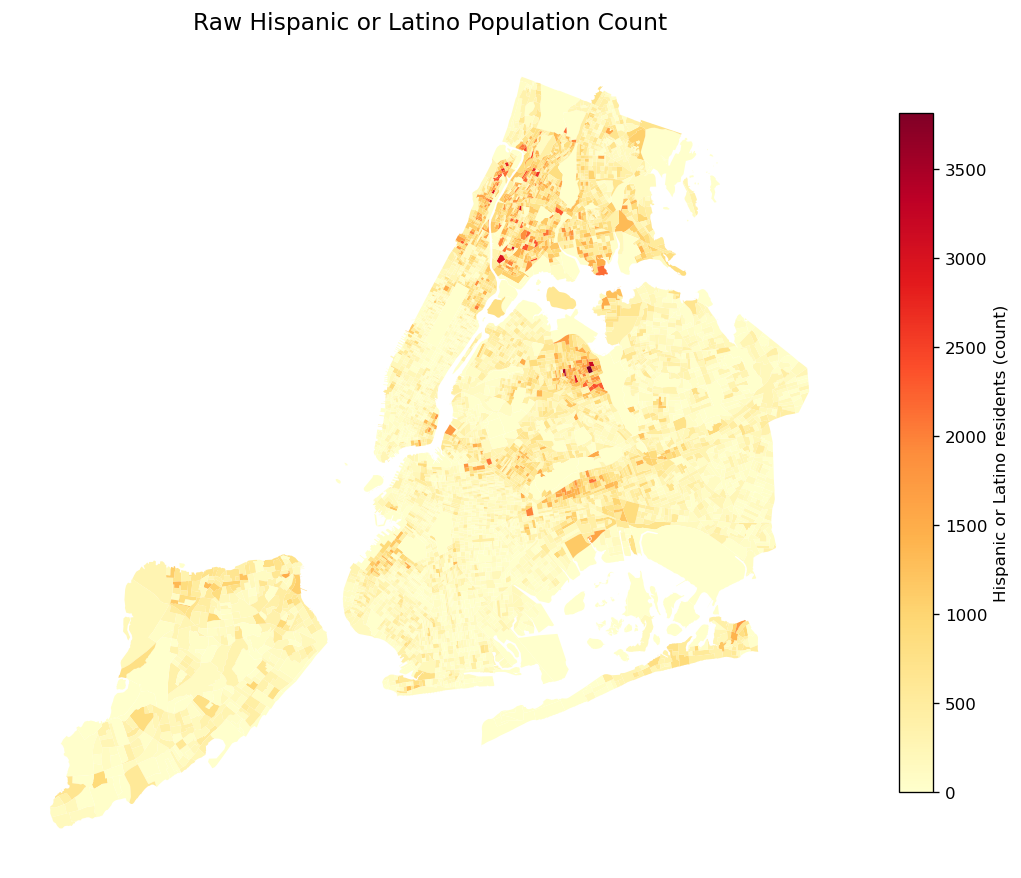

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))
census.plot(
    column=hispanic_count,
    cmap="YlOrRd",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"label": "Hispanic or Latino residents (count)", "shrink": 0.65},
)
ax.set_title("Raw Hispanic or Latino Population Count")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
census[hispanic_count].describe().round(2)

count    6593.00
mean      367.07
std       418.87
min         0.00
25%        76.00
50%       219.00
75%       518.00
max      3816.00
Name: Hispanic or Latino, dtype: float64

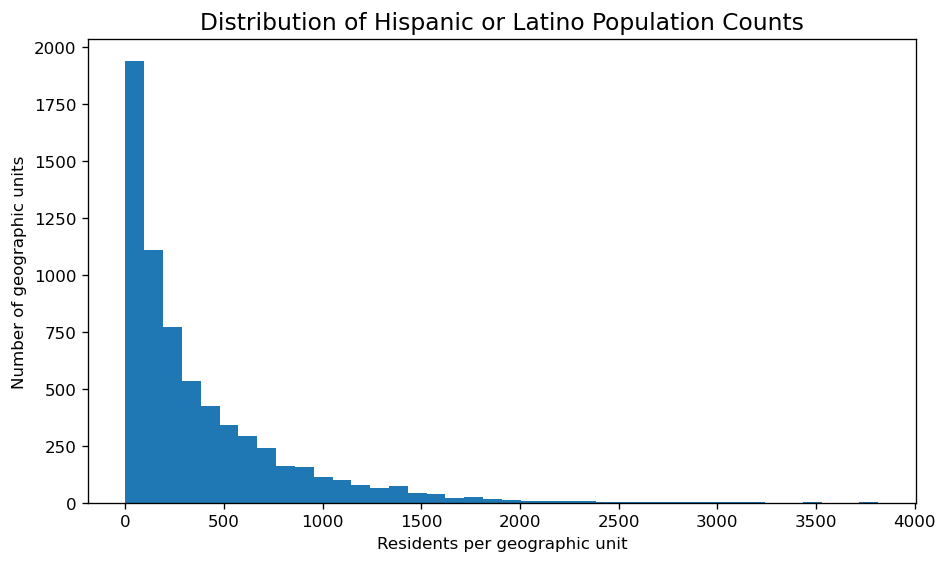

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(census[hispanic_count].dropna(), bins=40)
ax.set_title("Distribution of Hispanic or Latino Population Counts")
ax.set_xlabel("Residents per geographic unit")
ax.set_ylabel("Number of geographic units")
plt.tight_layout()
plt.show()

The histogram is right-skewed: many geographic units contain relatively small counts, while a smaller number contain much larger counts. The raw-count map therefore emphasizes large or populous units. It cannot tell us whether Hispanic or Latino residents form a large share of the local population.


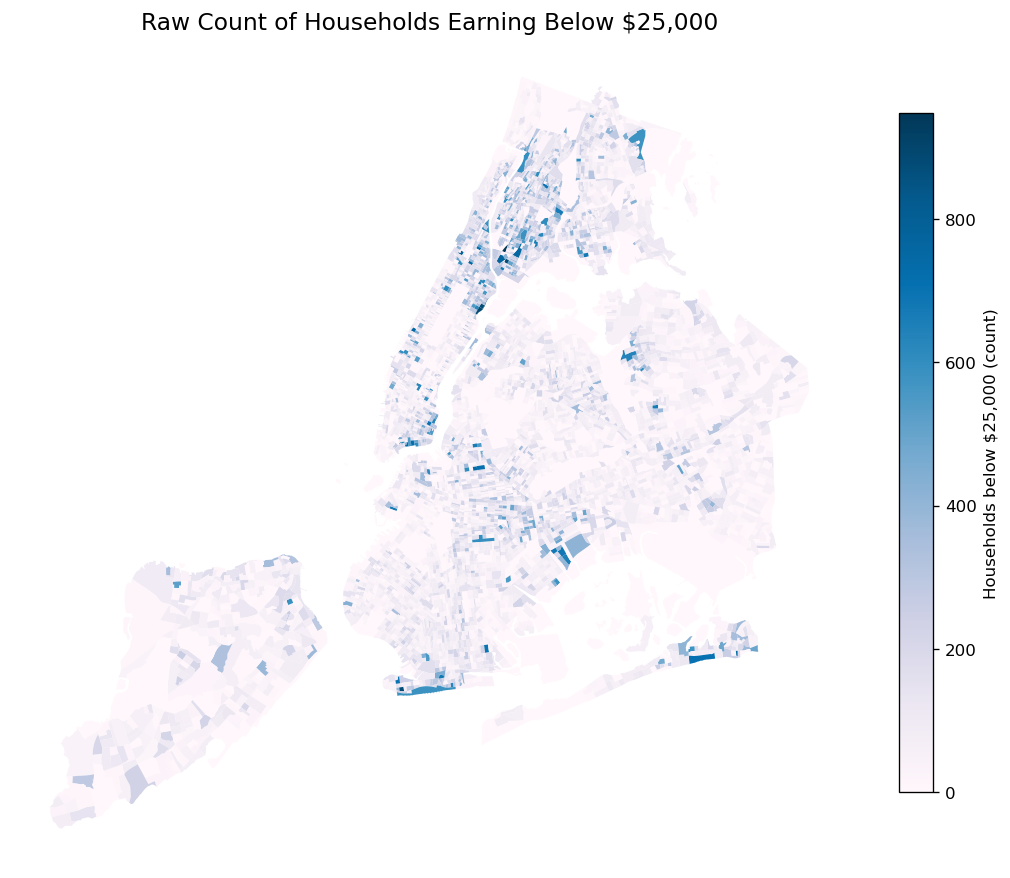

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
census.plot(
    column="low_income_households",
    cmap="PuBu",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"label": "Households below $25,000 (count)", "shrink": 0.65},
)
ax.set_title("Raw Count of Households Earning Below $25,000")
ax.set_axis_off()
plt.tight_layout()
plt.show()

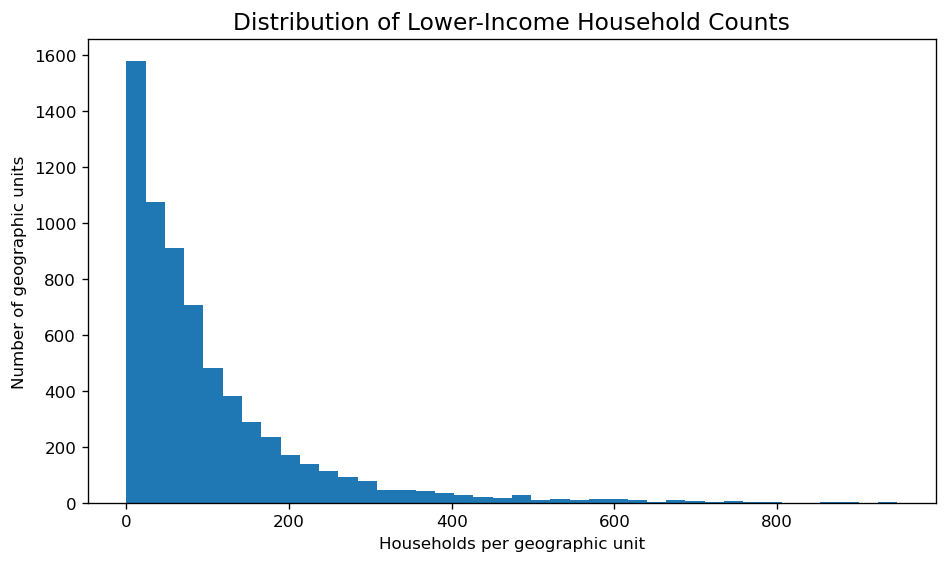

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(census["low_income_households"].dropna(), bins=40)
ax.set_title("Distribution of Lower-Income Household Counts")
ax.set_xlabel("Households per geographic unit")
ax.set_ylabel("Number of geographic units")
plt.tight_layout()
plt.show()

Again, the count is partly a measure of how many households exist in each unit. To compare places more fairly, I normalize each numerator by its relevant denominator.


## 5. Normalize the variables

I calculate percentages only where the denominator is greater than zero. This avoids division-by-zero errors and distinguishes missing/undefined percentages from true zero values.


In [11]:
census["hispanic_pct"] = np.where(
    census[pop_total] > 0,
    100 * census[hispanic_count] / census[pop_total],
    np.nan,
)

census["low_income_pct"] = np.where(
    census[hh_total] > 0,
    100 * census["low_income_households"] / census[hh_total],
    np.nan,
)

# Population density is included as a methodological comparison to the course tutorial.
census["population_density"] = np.where(
    census["Area (Sq Mi)"] > 0,
    census[pop_total] / census["Area (Sq Mi)"],
    np.nan,
)

analysis = census.loc[
    (census[pop_total] > 0) & (census[hh_total] > 0) & census.geometry.notna()
].copy()

analysis[["hispanic_pct", "low_income_pct", "population_density"]].describe().round(2)

,hispanic_pct,low_income_pct,population_density
count,6365.00,6365.00,6365.00
mean,27.76,18.82,65951.70
std,24.90,16.34,56167.09
min,0.00,0.00,7.02
25%,8.03,6.83,27755.86
50%,19.66,14.67,50069.63
75%,42.52,26.26,86292.70
max,100.00,100.00,561525.39


### Why percentages instead of counts?

- **Counts** indicate how many people or households are represented.
- **Percentages** indicate the composition of a geographic unit.
- **Density** indicates concentration relative to land area.

None is universally correct. The appropriate measure depends on the research question. Here, percentages are most useful because I am comparing social composition across differently sized units.


## 6. Percentage distributions

The histograms show how common different percentage values are across the city. They are necessary because a map reveals location but makes exact distributional shape difficult to judge.


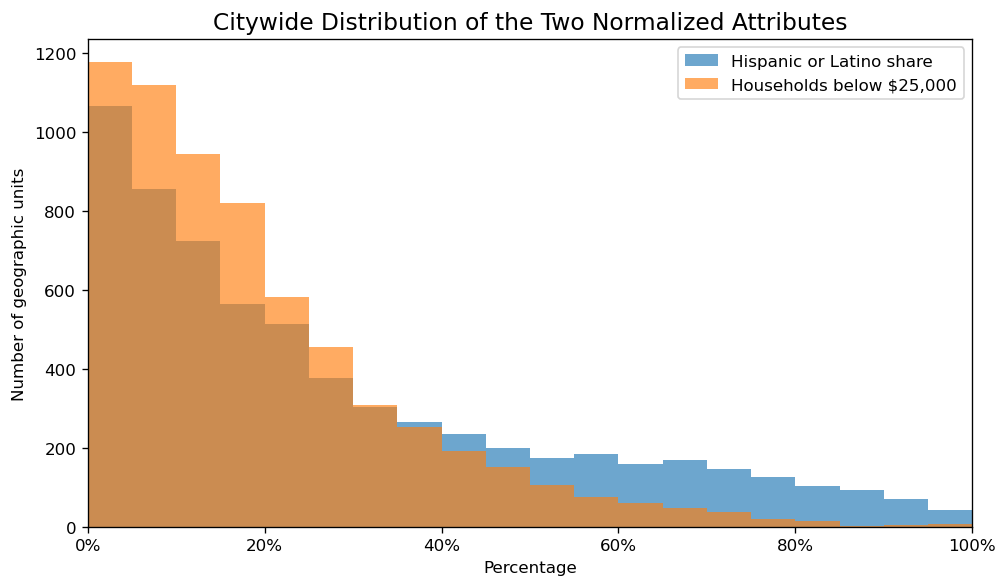

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(
    analysis["hispanic_pct"].dropna(),
    bins=np.arange(0, 105, 5),
    alpha=0.65,
    label="Hispanic or Latino share",
)
ax.hist(
    analysis["low_income_pct"].dropna(),
    bins=np.arange(0, 105, 5),
    alpha=0.65,
    label="Households below $25,000",
)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Percentage")
ax.set_ylabel("Number of geographic units")
ax.set_title("Citywide Distribution of the Two Normalized Attributes")
ax.legend()
plt.tight_layout()
plt.show()

The two distributions differ in shape and spread. Hispanic share extends across nearly the entire 0–100% range, while lower-income household share is more concentrated. This means identical class breaks would not necessarily reveal comparable internal variation.


## 7. Fixed-scale maps

For the first percentage maps I use the same 0–100% scale. This makes the legends directly comparable and preserves the substantive meaning of percentage values.


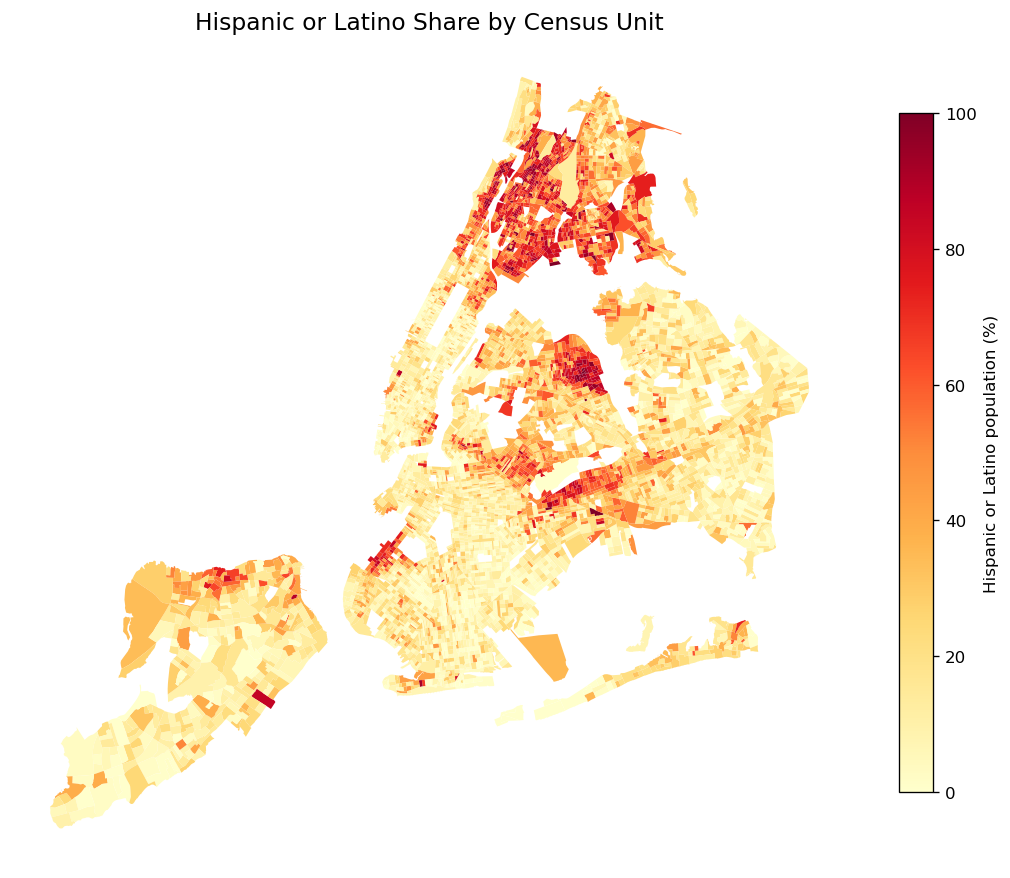

In [13]:
fig, ax = plt.subplots(figsize=(9, 9))
analysis.plot(
    column="hispanic_pct",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"label": "Hispanic or Latino population (%)", "shrink": 0.65},
)
ax.set_title("Hispanic or Latino Share by Census Unit")
ax.set_axis_off()
plt.tight_layout()
plt.show()

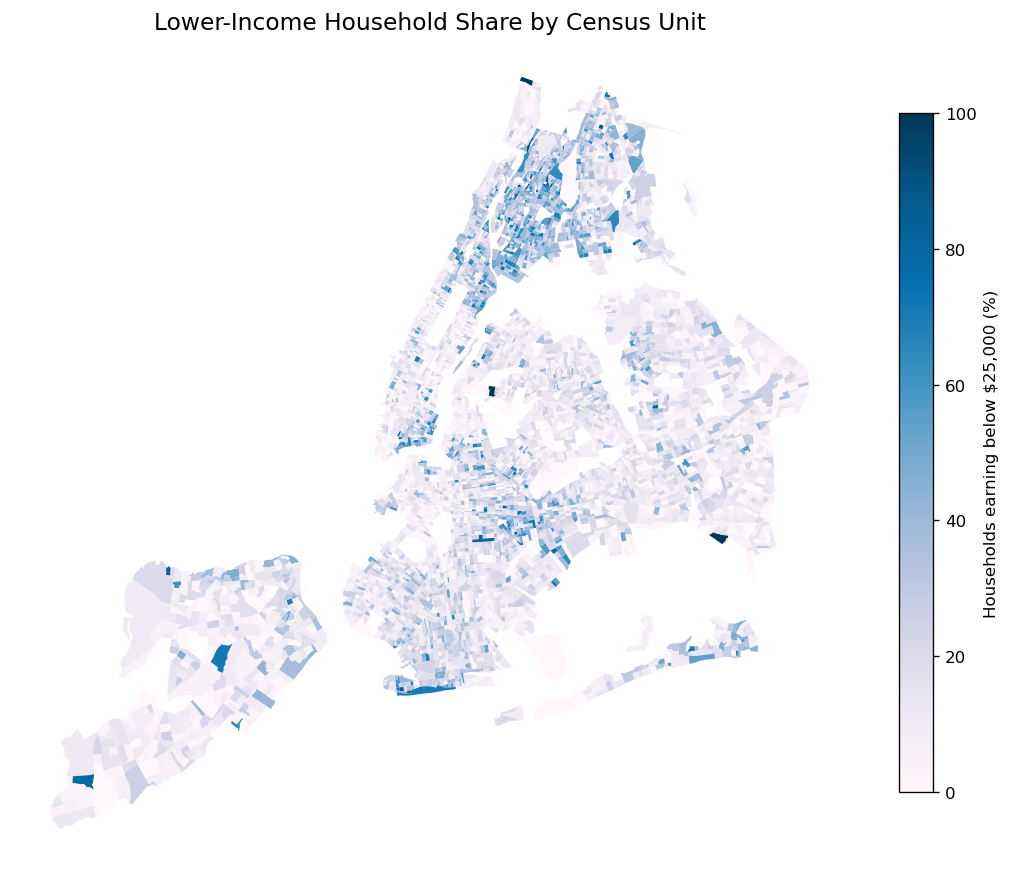

In [14]:
fig, ax = plt.subplots(figsize=(9, 9))
analysis.plot(
    column="low_income_pct",
    cmap="PuBu",
    vmin=0,
    vmax=100,
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"label": "Households earning below $25,000 (%)", "shrink": 0.65},
)
ax.set_title("Lower-Income Household Share by Census Unit")
ax.set_axis_off()
plt.tight_layout()
plt.show()

The maps suggest spatial clustering rather than random distribution. Some parts of the Bronx, Brooklyn, and Queens appear elevated on one or both measures, while many areas of Manhattan and Staten Island differ. These are visual observations, not causal explanations.


## 8. Quantile maps as an alternative classification

A fixed 0–100 scale is substantively clear, but it can compress variation if most observations occupy a narrower range. Quantile classification assigns roughly equal numbers of geographic units to each class.

To avoid an extra `mapclassify` dependency, I calculate quintiles with `pandas.qcut`.


In [15]:
analysis["hispanic_quintile"] = pd.qcut(
    analysis["hispanic_pct"],
    q=5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
    duplicates="drop",
)

analysis["low_income_quintile"] = pd.qcut(
    analysis["low_income_pct"],
    q=5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
    duplicates="drop",
)

analysis[
    ["hispanic_pct", "hispanic_quintile", "low_income_pct", "low_income_quintile"]
].head()

,hispanic_pct,hispanic_quintile,low_income_pct,low_income_quintile
0,0.521241,Q1 lowest,5.154639,Q1 lowest
1,20.747253,Q3,44.535519,Q5 highest
2,29.062647,Q4,42.204900,Q5 highest
3,8.333333,Q2,32.538569,Q5 highest
4,58.244111,Q5 highest,60.130719,Q5 highest


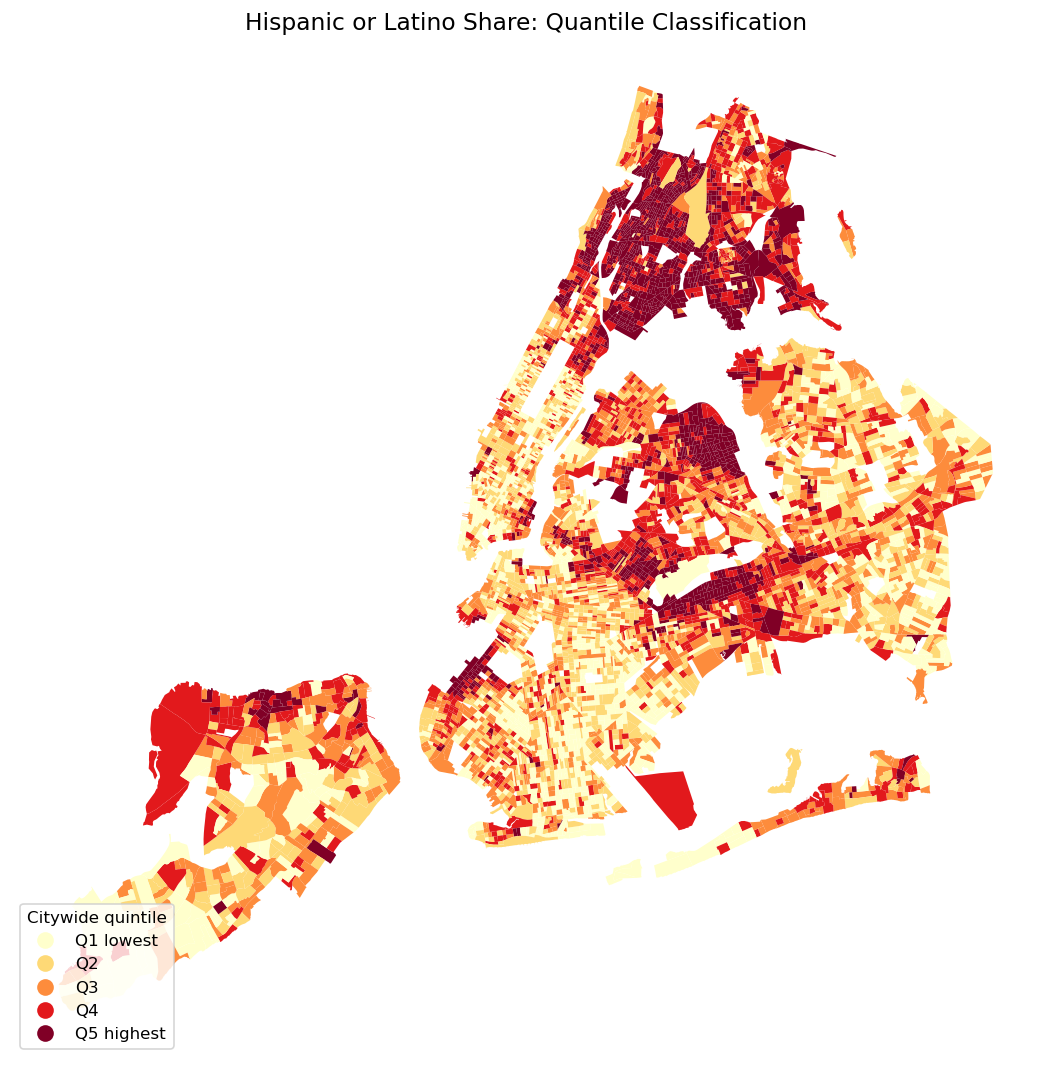

In [16]:
fig, ax = plt.subplots(figsize=(9, 9))
analysis.plot(
    column="hispanic_quintile",
    categorical=True,
    cmap="YlOrRd",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"title": "Citywide quintile", "loc": "lower left"},
)
ax.set_title("Hispanic or Latino Share: Quantile Classification")
ax.set_axis_off()
plt.tight_layout()
plt.show()

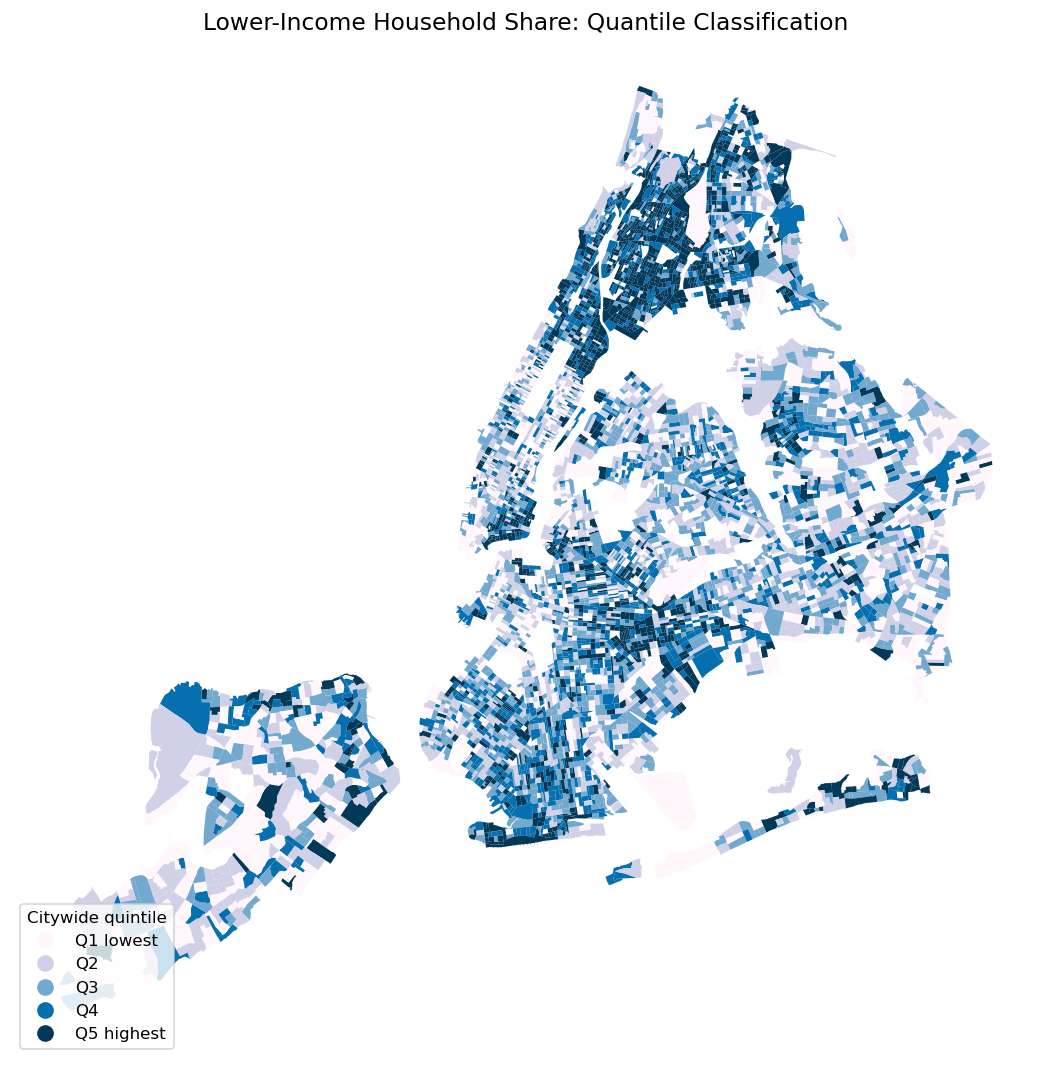

In [17]:
fig, ax = plt.subplots(figsize=(9, 9))
analysis.plot(
    column="low_income_quintile",
    categorical=True,
    cmap="PuBu",
    legend=True,
    linewidth=0,
    ax=ax,
    legend_kwds={"title": "Citywide quintile", "loc": "lower left"},
)
ax.set_title("Lower-Income Household Share: Quantile Classification")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Quantile maps make relative rank easier to see, but their class labels do **not** represent equal percentage intervals. Two adjacent quintiles may be separated by only a small numerical difference. Therefore, quantile maps are useful for identifying relative position within NYC but less useful for communicating absolute magnitude.


## 9. Relationship between the two attributes

A scatterplot removes geography temporarily and asks whether geographic units with higher Hispanic shares also tend to have higher lower-income household shares. I add a linear trend and report Pearson correlation as a descriptive summary.


Pearson correlation: 0.334


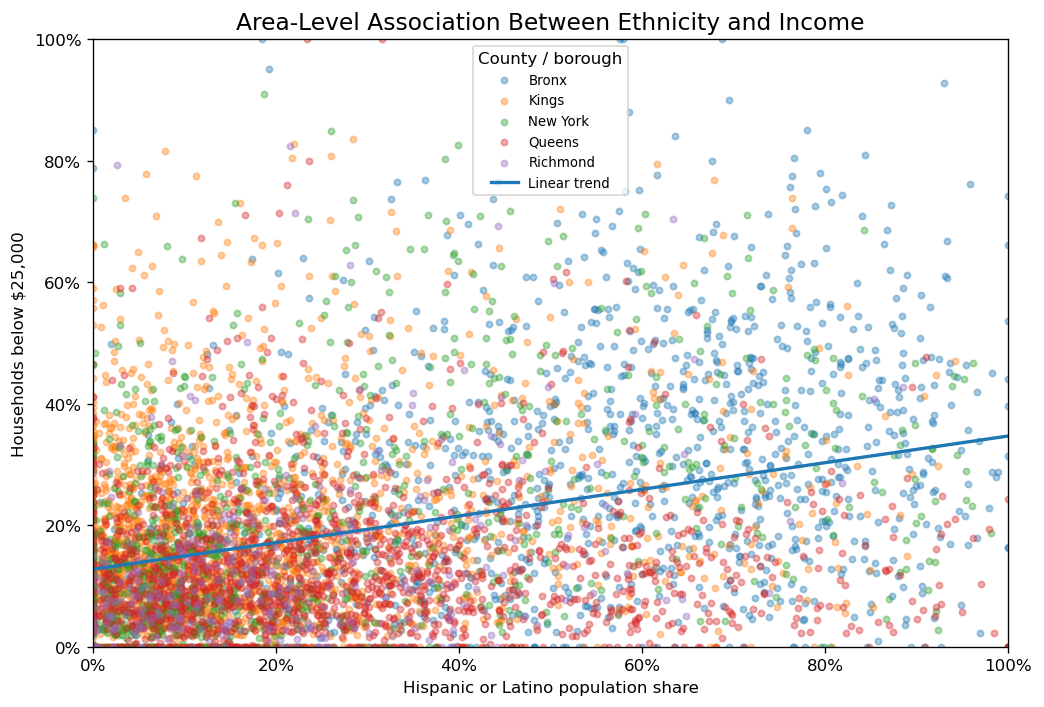

In [18]:
scatter = (
    analysis[["hispanic_pct", "low_income_pct", pop_total, "COUNTY"]].dropna().copy()
)

corr = scatter["hispanic_pct"].corr(scatter["low_income_pct"])
print(f"Pearson correlation: {corr:.3f}")

fig, ax = plt.subplots(figsize=(8.8, 6))

for county, group in scatter.groupby("COUNTY"):
    ax.scatter(
        group["hispanic_pct"],
        group["low_income_pct"],
        s=14,
        alpha=0.38,
        label=county.replace(" County", ""),
    )

x = scatter["hispanic_pct"].to_numpy()
y = scatter["low_income_pct"].to_numpy()
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(0, 100, 200)
ax.plot(x_line, m * x_line + b, linewidth=2, label="Linear trend")

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Hispanic or Latino population share")
ax.set_ylabel("Households below $25,000")
ax.set_title("Area-Level Association Between Ethnicity and Income")
ax.legend(title="County / borough", fontsize=8)
plt.tight_layout()
plt.show()

The correlation summarizes a citywide linear association between places. It does **not** mean that Hispanic identity causes low income, nor does it prove that the same individuals belong to both categories. Inferring individual characteristics from area-level data would risk the **ecological fallacy**.


## 10. Borough-level comparison

Borough summaries help contextualize citywide patterns, but a single average can hide large differences within each borough. I therefore use both a table and boxplots.


In [19]:
borough_summary = (
    analysis.groupby("COUNTY")
    .agg(
        geographic_units=("GISJOIN", "count"),
        median_hispanic_share=("hispanic_pct", "median"),
        median_low_income_share=("low_income_pct", "median"),
        mean_hispanic_share=("hispanic_pct", "mean"),
        mean_low_income_share=("low_income_pct", "mean"),
    )
    .round(1)
    .sort_values("median_low_income_share", ascending=False)
)

borough_summary

,geographic_units,median_hispanic_share,median_low_income_share,mean_hispanic_share,mean_low_income_share
COUNTY,,,,,
Bronx County,1124,56.9,27.7,54.5,29.8
Kings County,2059,12.9,15.2,18.5,18.4
New York County,1147,12.5,13.3,22.0,18.2
Queens County,1710,21.4,11.2,26.7,13.5
Richmond County,325,15.1,9.9,20.2,13.7


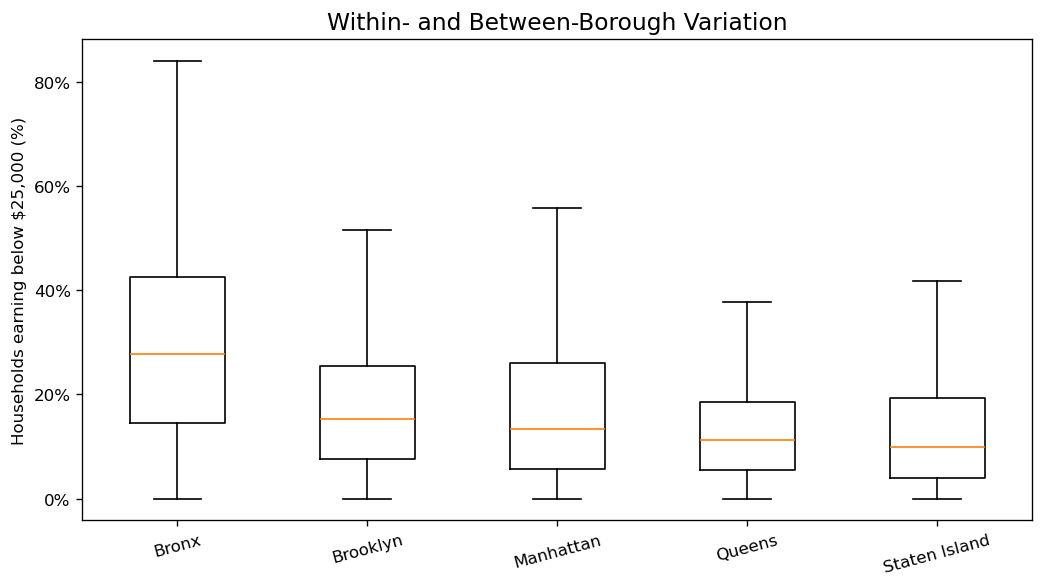

In [20]:
borough_order = [
    "Bronx County",
    "Kings County",
    "New York County",
    "Queens County",
    "Richmond County",
]
borough_labels = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

box_data = [
    analysis.loc[analysis["COUNTY"] == county, "low_income_pct"].dropna()
    for county in borough_order
]

fig, ax = plt.subplots(figsize=(8.8, 5))
ax.boxplot(box_data, tick_labels=borough_labels, showfliers=False)
ax.set_ylabel("Households earning below $25,000 (%)")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title("Within- and Between-Borough Variation")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

The boxplots show that boroughs are not internally uniform. Even when one borough has a higher median, its distribution may overlap substantially with others. This cautions against treating borough identity as a complete explanation of neighborhood conditions.


## 11. What the attributes can and cannot tell us

### What they can tell us

- The relative share of residents identifying as Hispanic or Latino in each census unit.
- The relative share of households reporting annual income below $25,000.
- Where high and low values cluster spatially.
- Whether the two area-level percentages are statistically associated.
- How distributions differ across and within boroughs.

### What they cannot tell us

- The identity or income of any individual resident.
- Why observed spatial patterns exist.
- Whether one attribute causes the other.
- Household wealth, debt, assets, rent burden, or cost-of-living pressure.
- Differences within broad income brackets.
- The precision of estimates when margins of error are absent.
- How results would change under different geographic boundaries.

A high percentage can also occur in a unit with a small denominator. For policy decisions, percentages should be read alongside counts, denominator size, and uncertainty.


## 12. Final interpretation

The strongest finding is not simply that ethnicity and income vary across New York City; it is that **the map changes depending on how the attribute is defined and classified**.

Raw counts emphasize places with more residents or households. Percentages reveal local composition. Fixed scales preserve absolute meaning, while quantiles sharpen relative differences. The scatterplot suggests whether the two percentages co-vary, but it cannot establish causation or individual-level relationships.

For a final colloquium project, this analysis could be extended by adding flood exposure, rent burden, disability, age, transit access, or housing tenure. A more rigorous version should also incorporate margins of error and test whether conclusions remain stable at different geographic scales.


## Key concepts

- **Normalization:** converting a count into a rate, percentage, or density using a relevant denominator.
- **Choropleth map:** a map in which areas are shaded according to an attribute value.
- **Quantile classification:** dividing observations so each class contains roughly the same number of geographic units.
- **Ecological fallacy:** incorrectly assigning area-level relationships to individuals.
- **Modifiable Areal Unit Problem (MAUP):** the possibility that statistical patterns change when geographic boundaries or scales change.
- **Correlation:** a measure of association, not proof of causation.
